# House Price Prediction Project

## Project Objective
The goal of this project is to build a machine learning model 
that predicts house prices based on features such as median income, 
house age, average rooms, and geographic location (latitude & longitude).

The dataset used is the California Housing dataset.

## Import Libraries

In this section we import the libraries needed for:
- Data analysis
- Data visualization
- Numerical operations

In [141]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

- NumPy is used for numerical operations.
- Pandas is used for data manipulation and analysis.
- Matplotlib is used for data visualization.
- Seaborn is used for statistical data visualization.

## Load Dataset
In this section we load the California Housing dataset 
into a pandas DataFrame using scikit-learn's built-in datasets module.

In [142]:
df = pd.read_csv('housing.csv')

## Preview Dataset
We display the first 5 rows of the dataset to get an initial 
understanding of the available columns and data structure.

In [143]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Dataset Columns

- longitude → Geographic longitude location
- latitude → Geographic latitude location
- housing_median_age → Median age of houses
- total_rooms → Total number of rooms
- total_bedrooms → Total number of bedrooms
- population → Population in the area
- households → Number of households
- median_income → Median income of residents
- median_house_value → Target variable (house price)
- ocean_proximity → Distance from ocean

## Dataset Information

In this section we explore:
- Number of rows and columns
- Data types
- Missing values

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### Observations

- The dataset contains 20,640 rows and 10 columns.
- Most columns are numerical features with `float64` data type.
- `ocean_proximity` is a categorical feature with `object` data type.
- The `total_bedrooms` column contains missing values because it has 20,433 non-null values instead of 20,640.
- Missing values must be handled before training the machine learning model.

## Statistical Summary

We use `describe()` to explore the statistical properties of numerical columns such as:
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

In [145]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Observations

- The average house value is around 206,855.
- The median income average is approximately 3.87.
- Some columns such as `total_rooms`, `population`, and `total_bedrooms` contain very large maximum values, indicating possible outliers.
- The housing median age ranges from 1 to 52 years.
- The target variable `median_house_value` has a maximum value of 500,001, which may indicate a price cap in the dataset.
- The large standard deviation in several columns suggests high variability in the data.

# Data Cleaning

## Missing Values

We check for missing values in each column before data preprocessing.

In [146]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### Observations

- Most columns do not contain missing values.
- The `total_bedrooms` column contains missing values.
- Missing values need to be handled before training the machine learning model to avoid errors and improve model performance.

## Handle Missing Values

We fill missing values in the `total_bedrooms` column using the median value.

The median is preferred because it is less sensitive to outliers compared to the mean.

In [147]:
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].median())

### Why We Used Median

- The dataset contains large values and possible outliers.
- Using the median provides a more robust replacement for missing values.
- This step ensures there are no missing values before model training.

## Verify Missing Values

After handling missing values, we check the dataset again to confirm that no null values remain.

In [148]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

### Observations

- All missing values have been successfully handled.
- The dataset is now clean and ready for exploratory data analysis and machine learning.

## Check Duplicate Rows

We check whether the dataset contains duplicate rows that could negatively affect the analysis and model performance.

In [149]:
df.duplicated().sum()

np.int64(0)

### Observations

- The dataset does not contain duplicate rows.
- No duplicate removal is required.
- The dataset is now clean and ready for further analysis.

# Exploratory Data Analysis (EDA)

## Distribution of House Prices

We visualize the distribution of house prices to better understand how the target variable is spread across the dataset.

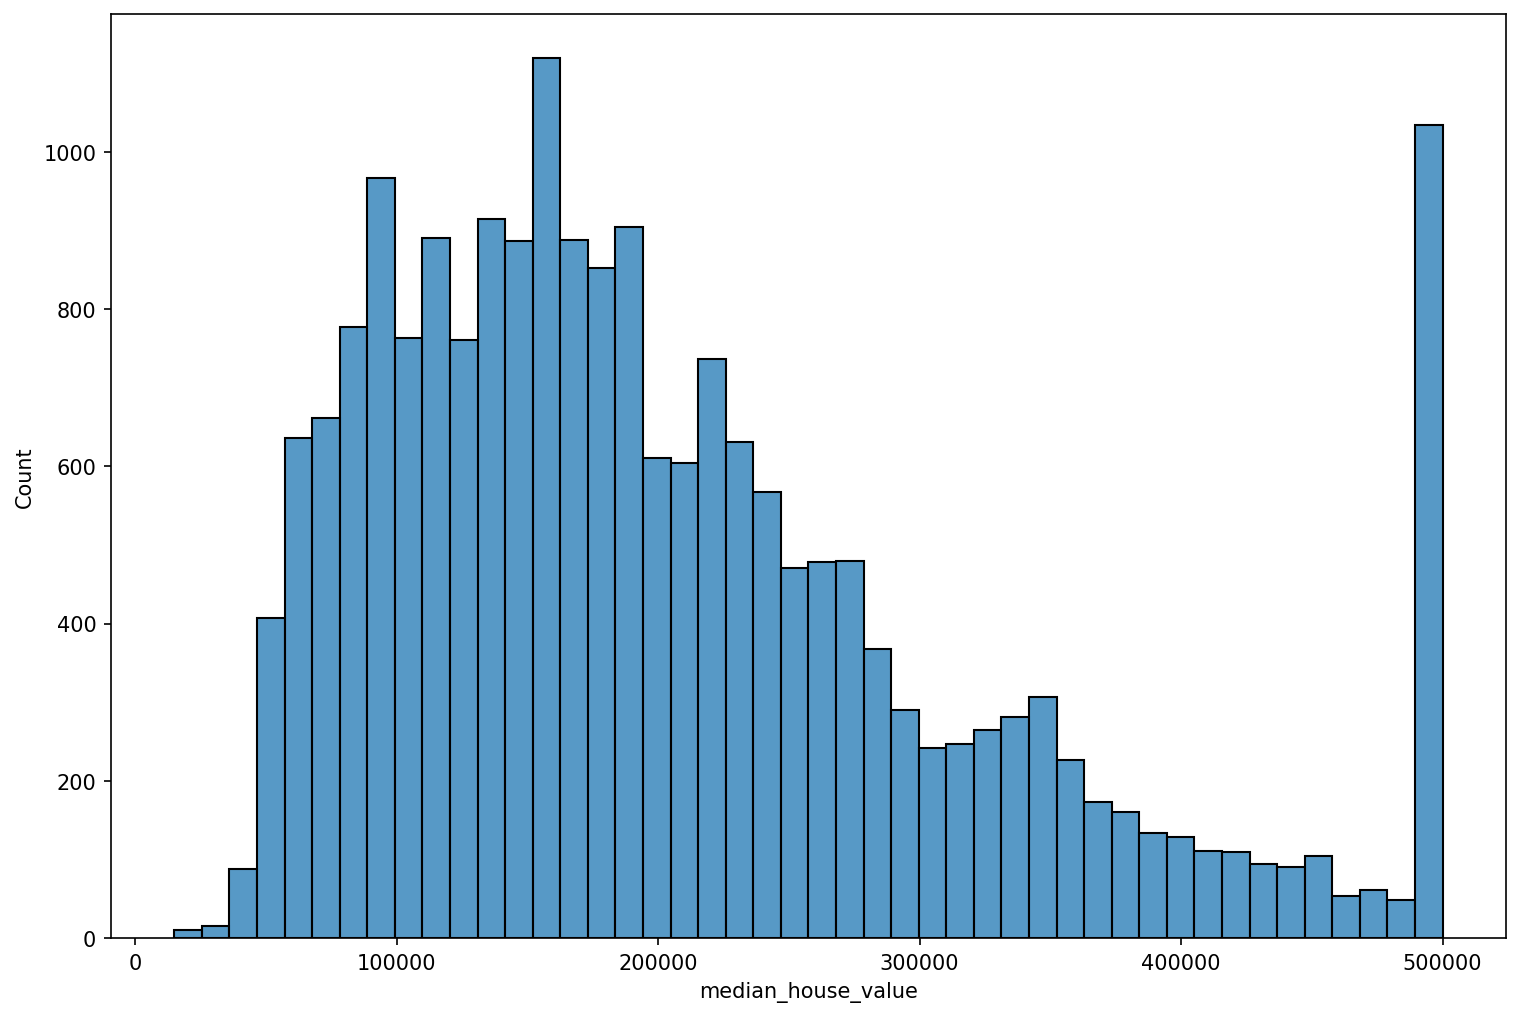

In [150]:
plt.figure(figsize=(12,8),dpi=150)
sns.histplot(df['median_house_value'])
plt.show()

### Observations

- The distribution of house prices is right-skewed.
- Most houses are concentrated between approximately 50,000 and 300,000.
- There is a noticeable spike around 500,000, which suggests that house prices may have been capped at this value in the dataset.
- Very high-priced houses are less common compared to lower-priced houses.
- Understanding the target variable distribution helps in selecting and evaluating machine learning models.

## Correlation Analysis

In [151]:
corr = df.corr(numeric_only=True)
corr['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

### Observations

- `median_income` has the strongest positive correlation with house prices, making it one of the most important features in the dataset.
- Houses located near the bay or ocean tend to have higher prices.
- `room_per_household` shows a positive relationship with house values, suggesting that houses with more rooms per household are generally more expensive.
- `ocean_proximity_INLAND` has a strong negative correlation, meaning inland houses are usually less expensive.
- `bedrooms_per_room` has a negative correlation with house prices, which may indicate lower house quality or smaller room sizes.
- Features such as `population` and `longitude` have weak correlations with the target variable.

## Correlation Heatmap

We visualize the correlation matrix using a heatmap to better understand the relationships between numerical features.

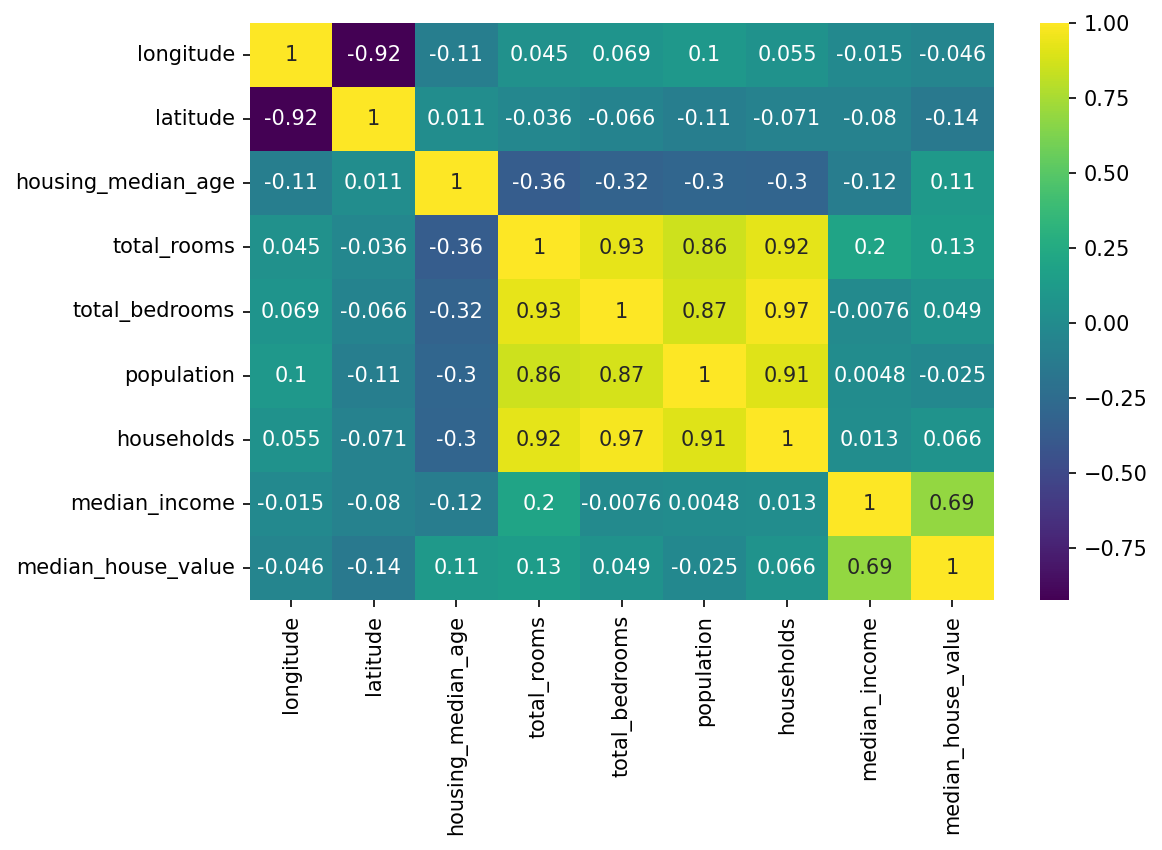

In [152]:
plt.figure(figsize=(8,5),dpi=150)
sns.heatmap(corr,annot=True,cmap="viridis")
plt.show()

### Observations

- `median_income` shows the strongest positive correlation with `median_house_value`.
- `total_rooms`, `total_bedrooms`, `population`, and `households` are highly correlated with each other.
- `longitude` and `latitude` have a strong negative correlation.
- Most features show weak to moderate correlation with the target variable.
- Heatmaps help identify important relationships and possible multicollinearity between features.

## Ocean Proximity Distribution

We analyze the frequency of each category in the `ocean_proximity` column.

In [153]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### Observations

- Most houses are located near the ocean.
- The `ISLAND` category contains very few records.
- The categorical distribution is imbalanced.

In [154]:
df = pd.get_dummies(df,drop_first=True,dtype=int)

## Encoding Categorical Features

We convert categorical variables into numerical format using One Hot Encoding so the machine learning model can process them.

In [155]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

### Observations

- Categorical variables were successfully converted into numerical features.
- One Hot Encoding creates separate columns for each category.
- Converting boolean values to integers ensures compatibility with machine learning models.

## Preview Encoded Dataset

We display the first rows of the dataset after encoding categorical variables.

In [156]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


### Observations

- The categorical column was successfully transformed into numerical columns.
- New encoded features were added to the dataset.
- The dataset is now ready for machine learning preprocessing.

# Data Preprocessing

## Define Features and Target Variable

In [157]:
X=df.drop('median_house_value',axis=1)
y=df['median_house_value']

### Observations

- `X` contains all input features used for prediction.
- `y` contains the target variable (`median_house_value`).
- Separating features and target is an important step before training machine learning models.

# Model Building

## Import Machine Learning Tools
We import the required tools for splitting the dataset, training the model, and evaluating performance.

In [158]:
from sklearn.model_selection import train_test_split

## Split Dataset

We split the dataset into training and testing sets to evaluate the model on unseen data.

In [159]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

### Observations

- 80% of the data is used for training.
- 20% of the data is used for testing.
- `random_state=42` ensures reproducible results.

## Import Linear Regression Model

We import the Linear Regression model as a baseline machine learning algorithm for predicting house prices.

In [160]:
from sklearn.linear_model import LinearRegression

## Initialize the Model

We create an instance of the Linear Regression model.

In [161]:
model = LinearRegression()

### Observations

- The model is initialized and ready for training.
- Linear Regression attempts to model the relationship between features and the target variable using a linear equation.

## Train the Model

We train the Linear Regression model using the training dataset.

In [162]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Observations

- The model learns patterns and relationships from the training data.
- During training, the model adjusts its parameters to minimize prediction errors.

## Make Predictions

We use the trained model to predict house prices on the testing dataset.

In [163]:
model_predict = model.predict(X_test)

### Observations

- The model generates predicted house prices for unseen data.
- These predictions will be used to evaluate model performance.

## Import Evaluation Metrics

We import evaluation metrics to measure the performance of the machine learning model.

In [164]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

### Observations

- MAE measures the average absolute prediction error.
- MSE measures the average squared error.
- R² Score measures how well the model explains the variance in the target variable.

## Evaluate Model Performance

We evaluate the model using multiple regression metrics.

In [165]:
mae = mean_absolute_error(y_test,model_predict)
mse = mean_squared_error(y_test,model_predict)
r2_=r2_score(y_test,model_predict)

### Observations

- Lower MAE and MSE values indicate better prediction accuracy.
- Higher R² values indicate better model performance.
- These metrics help measure how well the model predicts house prices.

In [166]:
mae

50670.73824097183

### Observations

- The model predictions differ from the actual house prices by approximately 50,670 on average.
- This indicates the average prediction error magnitude of the Linear Regression model.

In [167]:
mse

4908476721.156621

### Observations

- The Mean Squared Error is relatively large because prediction errors are squared.
- MSE penalizes large prediction errors more heavily than MAE.
- Lower MSE values indicate better model performance.

In [168]:
r2_

0.6254240620553602

### Observations

- The model explains approximately 44% of the variance in house prices.
- This indicates that Linear Regression captures part of the relationship between features and house prices, but the performance is moderate.
- More advanced models may improve prediction accuracy.

# Feature Engineering

## Create New Features
We create new features from existing columns to improve model performance and capture additional relationships in the data.

In [169]:
df['room_per_household']=(df['total_rooms']/df['households'])
df['bedrooms_per_room']=(df['total_bedrooms']/df['total_rooms'])
df['population_per_house']=(df['population']/df['households'])

### Observations

- New informative features were created from existing numerical columns.
- Feature engineering can help machine learning models capture hidden patterns in the dataset.
- These new features may improve prediction accuracy.

## Preview Dataset After Feature Engineering

We display the dataset after creating new engineered features.

In [170]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,room_per_household,bedrooms_per_room,population_per_house
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0,6.281853,0.172096,2.181467


### Observations

- New engineered features were successfully added to the dataset.
- The dataset now contains additional information that may improve model performance.

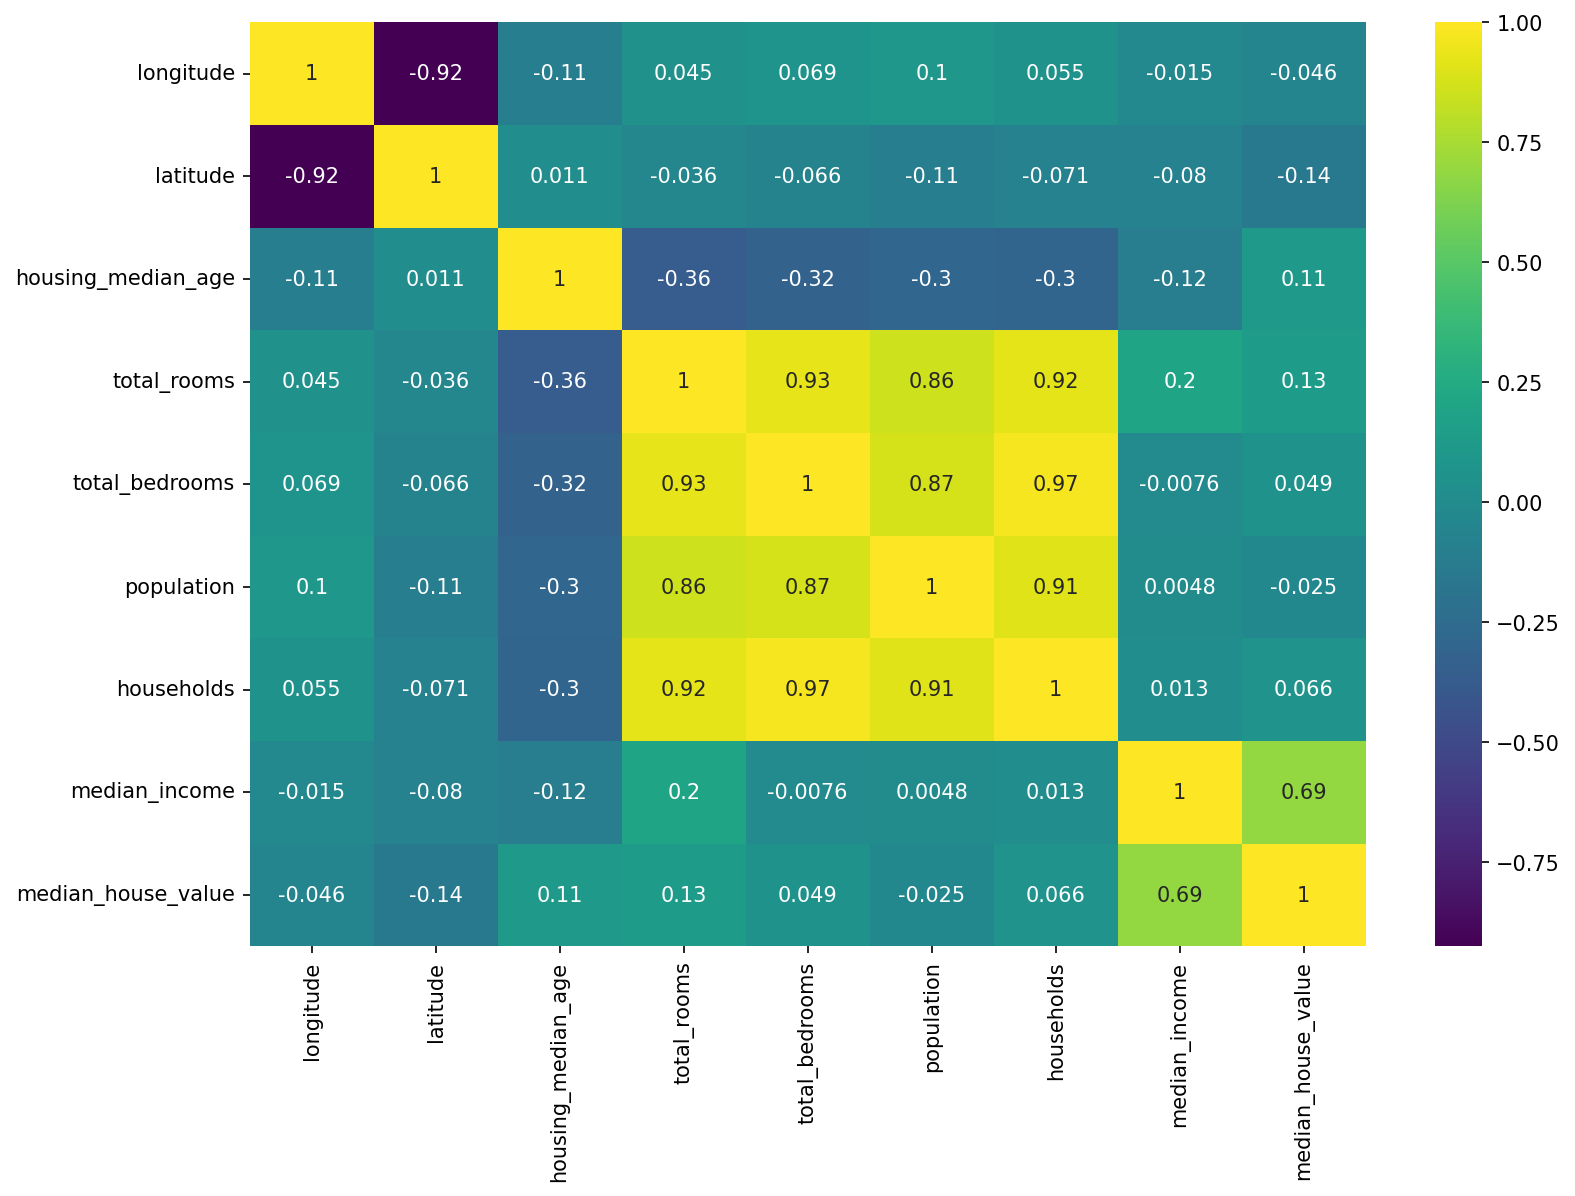

In [171]:
plt.figure(figsize=(12,8),dpi=150)
sns.heatmap(corr,annot=True,cmap="viridis")
plt.show()

### Observations

- `median_income` still has the strongest positive correlation with house prices.
- The engineered feature `room_per_household` shows a positive correlation with the target variable.
- `bedrooms_per_room` has a stronger negative correlation with house prices compared to several original features.
- Feature engineering helped create more informative variables for the machine learning model.
- Some features remain highly correlated with each other, indicating multicollinearity.

# Data Preprocessing

## Define Features and Target Variable

We separate the dataset into input features (`X`) and the target variable (`y`).

In [172]:
X=df.drop('median_house_value',axis = 1)
y= df['median_house_value']

### Observations

- `X` contains all independent variables used for prediction.
- `y` contains the target variable (`median_house_value`).
- This separation is required before training machine learning models.

## Split the Dataset

We split the dataset into training and testing sets to evaluate model performance on unseen data.

In [173]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

### Observations

- 80% of the dataset is used for training.
- 20% is reserved for testing.
- Using `random_state=42` ensures reproducible results.

# Model Building

## Import Random Forest Regressor

We import the Random Forest Regressor model for predicting house prices.

In [174]:
from sklearn.ensemble import RandomForestRegressor


### Observations

- Random Forest is an ensemble learning algorithm based on multiple decision trees.
- It can capture complex relationships in the dataset better than simple linear models.

## Initialize Random Forest Model

We create an instance of the Random Forest Regressor model.

In [175]:
rf= RandomForestRegressor()

### Observations

- The Random Forest model is initialized and ready for training.
- The model combines predictions from multiple decision trees to improve performance and reduce overfitting.

## Train the Random Forest Model

We train the Random Forest model using the training dataset.

In [176]:
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Observations

- The model learns patterns and relationships from the training data.
- Random Forest builds multiple decision trees during training to improve prediction accuracy.

## Make Predictions with Random Forest

In [177]:
rf_predict = rf.predict(X_test)

### Observations

- The trained Random Forest model generates predictions for the testing dataset.
- These predictions will be used to evaluate the model’s performance.

## Evaluate Random Forest Performance

In [178]:
r2=r2_score(y_test,rf_predict)

In [179]:
r2

0.8080375683672392

### Observations

- The Random Forest model achieved an R² score of approximately 0.81.
- This means the model explains about 81% of the variance in house prices.
- Random Forest significantly outperformed the Linear Regression model.
- The higher R² score indicates better prediction performance.

In [181]:
mae1 = mean_absolute_error(y_test,rf_predict)
mse1 = mean_squared_error(y_test,rf_predict)

In [182]:
mae1

32294.599462209302

In [183]:
mse1

2515492938.965246

# Hyperparameter Tuning

## Optimize Random Forest using GridSearchCV

We use GridSearchCV to search for the best combination of hyperparameters for the Random Forest model.

In [ ]:
from sklearn.model_selection import GridSearchCV
rf = RandomForestRegressor()
param_grid={
    'n_estimators':[100,200,300],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}
grid_search = GridSearchCV(rf,param_grid,cv=5,
                           scoring='r2',return_train_score=True)
grid_search.fit(X_train,y_train)

### Observations

- GridSearchCV tests multiple combinations of hyperparameters.
- Cross-validation (`cv=5`) helps evaluate model performance more reliably.
- The goal is to find the best model configuration that maximizes the R² score.

## Best Hyperparameters

In [187]:
grid_search.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

### Observations

- The best model uses 200 decision trees (`n_estimators=200`).
- `max_depth=None` allows trees to grow without a depth limit.
- `min_samples_split=2` means a node can split when at least 2 samples are available.
- These hyperparameters produced the best cross-validation performance during tuning.

## Best Cross-Validation Score

In [188]:
grid_search.best_score_

np.float64(0.8117511324619462)

### Observations

- The best cross-validation R² score achieved is approximately 0.81.
- This indicates that the optimized Random Forest model explains about 81% of the variance in house prices.
- The tuned model shows strong predictive performance and good generalization ability.

## Generate Predictions Using the Best Model

We use the optimized Random Forest model from GridSearchCV to generate predictions on the testing dataset.

In [129]:
best_predictions = grid_search.predict(X_test)

### Observations

- Predictions are generated using the best hyperparameter combination found during tuning.
- These predictions will be used to evaluate the final optimized model performance.

## Evaluate Optimized Model using MAE

In [132]:
mae2=mean_absolute_error(y_test,best_predictions)

In [131]:
mae2

32239.665643168602

### Observations

- The optimized Random Forest model achieved an MAE of approximately 32,240.
- On average, the model predictions differ from the actual house prices by about 32,240.
- The optimized model performs better than the earlier Linear Regression model.

## Mean Squared Error (MSE)

In [133]:
mse2 = mean_squared_error(y_test,best_predictions)

In [134]:
mse2

2508100261.269324

### Observations

- The optimized model achieved an MSE of approximately 2.5 billion.
- MSE values are usually large because prediction errors are squared.
- Lower MSE values indicate better model performance.
- MSE penalizes large prediction errors more heavily than MAE.

## Import Root Mean Squared Error Metric

We import the RMSE metric to evaluate prediction errors in the same unit as house prices.

In [135]:
from sklearn.metrics import root_mean_squared_error

## Root Mean Squared Error (RMSE)

In [136]:
rmse = root_mean_squared_error(y_test,best_predictions)

In [137]:
rmse

50080.93710454432

### Observations

- The optimized model achieved an RMSE of approximately 50,081.
- On average, the model predictions differ from actual house prices by around 50,000.
- RMSE is easier to interpret because it uses the same unit as the target variable.

## R² Score of the Optimized Model

In [138]:
r1_=r2_score(y_test,best_predictions)

In [139]:
r1_

0.8086017187827719

### Observations

- The optimized Random Forest model achieved an R² score of approximately 0.81.
- This means the model explains about 81% of the variance in house prices.
- The model demonstrates strong predictive performance after hyperparameter tuning.

# Save the Trained Model

## Export Model using Joblib

We save the trained machine learning model so it can be reused later without retraining.

In [185]:
import joblib

In [ ]:

joblib.dump(
    grid_search.best_estimator_,
    "house_price_model.pkl",
    compress=5
)

### Observations

- The optimized Random Forest model was successfully saved as a `.pkl` file.
- Saving the model allows it to be loaded later for deployment and prediction.
- This step is important for building production-ready machine learning applications.